Conduct Exploratory Data Analysis. This includes:

1. Open the file and read the whole dataset.
2. Check for any missing variables. If detected, with 2 methods show how you handle missing values. 
3. Verify the dataset for any duplicated rows. If duplicates are identified, eliminate them. 
4. Preform feature normalization between 0 and 1 if it is needed. Normalization helps to converge machine learning algorithms faster. 
5. Examine the dataset for categorical variables. If any are found, convert them to numerical variables.
6. Find correlations between the variables and visualize the correlation matrix using a b) heatmap (1 plot) and c) Scatterplot (minimum 2 plots). 
7. Designate all features, excluding the two last columns ("Next_Tmax" and "Next_Tmin"), as X_variables.
8. Add a column name "Next_Taverage". The values in this column is the average value of column "Next_Tmin" and "Next_Tmax".  Assign the "Next_Taverage" column as Y_variable.  
9. Remove correlated variables. Explain which variables should be removed and why. 

In [2]:
# Open the file and read the whole dataset.
import pandas as pd

df = pd.read_csv("M1 Forecast_Data_Set.csv")
print(df.shape)
print(df.dtypes)
df.head()

(7752, 25)
station             float64
Date                 object
Present_Tmax        float64
Present_Tmin        float64
LDAPS_RHmin         float64
LDAPS_RHmax         float64
LDAPS_Tmax_lapse    float64
LDAPS_Tmin_lapse    float64
LDAPS_WS            float64
LDAPS_LH            float64
LDAPS_CC1           float64
LDAPS_CC2           float64
LDAPS_CC3           float64
LDAPS_CC4           float64
LDAPS_PPT1          float64
LDAPS_PPT2          float64
LDAPS_PPT3          float64
LDAPS_PPT4          float64
lat                 float64
lon                 float64
DEM                 float64
Slope               float64
Solar radiation     float64
Next_Tmax           float64
Next_Tmin           float64
dtype: object


,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
0,1.0,2013-06-30,28.7,21.4,58.255688,91.116364,28.074101,23.006936,6.818887,69.451805,...,0.0,0.0,0.0,37.6046,126.991,212.3350,2.7850,5992.895996,29.1,21.2
1,2.0,2013-06-30,31.9,21.6,52.263397,90.604721,29.850689,24.035009,5.691890,51.937448,...,0.0,0.0,0.0,37.6046,127.032,44.7624,0.5141,5869.312500,30.5,22.5
2,3.0,2013-06-30,31.6,23.3,48.690479,83.973587,30.091292,24.565633,6.138224,20.573050,...,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5863.555664,31.1,23.9
3,4.0,2013-06-30,32.0,23.4,58.239788,96.483688,29.704629,23.326177,5.650050,65.727144,...,0.0,0.0,0.0,37.6450,127.022,45.7160,2.5348,5856.964844,31.7,24.3
4,5.0,2013-06-30,31.4,21.9,56.174095,90.155128,29.113934,23.486480,5.735004,107.965535,...,0.0,0.0,0.0,37.5507,127.135,35.0380,0.5055,5859.552246,31.2,22.5


**explanation**
- As shown in this initial inspection, there are 7752 rows, and 25 columns. 
- printed column names as well as their types for initial inspection

In [3]:
# Check for any missing variables. If detected, with 2 methods show how you handle missing values
df.isnull().sum()

station              2
Date                 2
Present_Tmax        70
Present_Tmin        70
LDAPS_RHmin         75
LDAPS_RHmax         75
LDAPS_Tmax_lapse    75
LDAPS_Tmin_lapse    75
LDAPS_WS            75
LDAPS_LH            75
LDAPS_CC1           75
LDAPS_CC2           75
LDAPS_CC3           75
LDAPS_CC4           75
LDAPS_PPT1          75
LDAPS_PPT2          75
LDAPS_PPT3          75
LDAPS_PPT4          75
lat                  0
lon                  0
DEM                  0
Slope                0
Solar radiation      0
Next_Tmax           27
Next_Tmin           27
dtype: int64

In [4]:
# method 1
# drop rows with missing numbers
df_drop = df.dropna()
print(f"Shape after dropping: {df_drop.shape}")

Shape after dropping: (7588, 25)


In [5]:
# method 2
# fill with mean
df_filled = df.fillna(df.mean(numeric_only=True))
print(f"Shape after filling: {df_filled.shape}")

Shape after filling: (7752, 25)


**Explained**
Method 1 (dropping) is simple but loses data. Method 2 (mean imputation) preserves all rows, which is better when data is limited.

In [6]:
# Verify the dataset for any duplicated rows. If duplicates are identified, eliminate them.
duplicated = df.duplicated().sum()
print(f"Duplicate rows: {duplicated}")

Duplicate rows: 0


**explanation**
no duplicated rows

In [7]:
# Preform feature normalization between 0 and 1 if it is needed.
# inspect features: 
df.describe()

,station,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,LDAPS_CC1,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
count,7750.000000,7682.000000,7682.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,...,7677.000000,7677.000000,7677.000000,7752.000000,7752.000000,7752.000000,7752.000000,7752.000000,7725.000000,7725.000000
mean,13.000000,29.768211,23.225059,56.759372,88.374804,29.613447,23.512589,7.097875,62.505019,0.368774,...,0.485003,0.278200,0.269407,37.544722,126.991397,61.867972,1.257048,5341.502803,30.274887,22.932220
std,7.211568,2.969999,2.413961,14.668111,7.192004,2.947191,2.345347,2.183836,33.730589,0.262458,...,1.762807,1.161809,1.206214,0.050352,0.079435,54.279780,1.370444,429.158867,3.128010,2.487613
min,1.000000,20.000000,11.300000,19.794666,58.936283,17.624954,14.272646,2.882580,-13.603212,0.000000,...,0.000000,0.000000,0.000000,37.456200,126.826000,12.370000,0.098475,4329.520508,17.400000,11.300000
25%,7.000000,27.800000,21.700000,45.963543,84.222862,27.673499,22.089739,5.678705,37.266753,0.146654,...,0.000000,0.000000,0.000000,37.510200,126.937000,28.700000,0.271300,4999.018555,28.200000,21.300000
50%,13.000000,29.900000,23.400000,55.039024,89.793480,29.703426,23.760199,6.547470,56.865482,0.315697,...,0.000000,0.000000,0.000000,37.550700,126.995000,45.716000,0.618000,5436.345215,30.500000,23.100000
75%,19.000000,32.000000,24.900000,67.190056,93.743629,31.710450,25.152909,8.032276,84.223616,0.575489,...,0.018364,0.007896,0.000041,37.577600,127.042000,59.832400,1.767800,5728.316406,32.600000,24.600000
max,25.000000,37.600000,29.900000,98.524734,100.000153,38.542255,29.619342,21.857621,213.414006,0.967277,...,21.621661,15.841235,16.655469,37.645000,127.135000,212.335000,5.178230,5992.895996,38.900000,29.800000


**explanation**

- Using Describe, I can see the data needs to be noramalized. 
- Looking at the mean, std, and min/max, the features are on a very difference scale. For exaple, solar radiation has a max of 5992 and slope has a max of 5.

In [8]:
#columns that need to be normalized.
cols_to_exclude = ['station', 'Date', 'Next_Tmax', 'Next_Tmin']

cols_to_normalize = [c for c in df.columns if c not in cols_to_exclude]

print(cols_to_normalize) 

['Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH', 'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1', 'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope', 'Solar radiation']


**explanation**
- finding features that need to be normalized, since there are columns such as "Date" that shouldn't be normalized
- The `cols_to_normalize` are my features

In [9]:
# normalize
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

df.head()

,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
0,1.0,2013-06-30,0.494318,0.543011,0.488518,0.783659,0.499546,0.569132,0.207447,0.365853,...,0.0,0.0,0.0,0.786017,0.533981,1.000000,0.528869,1.000000,29.1,21.2
1,2.0,2013-06-30,0.676136,0.553763,0.412406,0.771200,0.584480,0.636121,0.148053,0.288703,...,0.0,0.0,0.0,0.786017,0.666667,0.161990,0.081820,0.925703,30.5,22.5
2,3.0,2013-06-30,0.659091,0.645161,0.367024,0.609716,0.595982,0.670697,0.171575,0.150545,...,0.0,0.0,0.0,0.643008,0.750809,0.104702,0.032999,0.922242,31.1,23.9
3,4.0,2013-06-30,0.681818,0.650538,0.488316,0.914366,0.577497,0.589934,0.145848,0.349446,...,0.0,0.0,0.0,1.000000,0.634304,0.166759,0.479615,0.918280,31.7,24.3
4,5.0,2013-06-30,0.647727,0.569892,0.462078,0.760251,0.549257,0.600379,0.150325,0.535505,...,0.0,0.0,0.0,0.500530,1.000000,0.113360,0.080127,0.919835,31.2,22.5


**explanation**

- Using MinMaxScaler to normalize the features
- Values will land between 0 and 1 as shown in the results
- All data are now on the same scale for fair comparison

In [10]:
# Examine the dataset for categorical variables. If any are found, convert them to numerical variables.
print(df.dtypes)

station             float64
Date                 object
Present_Tmax        float64
Present_Tmin        float64
LDAPS_RHmin         float64
LDAPS_RHmax         float64
LDAPS_Tmax_lapse    float64
LDAPS_Tmin_lapse    float64
LDAPS_WS            float64
LDAPS_LH            float64
LDAPS_CC1           float64
LDAPS_CC2           float64
LDAPS_CC3           float64
LDAPS_CC4           float64
LDAPS_PPT1          float64
LDAPS_PPT2          float64
LDAPS_PPT3          float64
LDAPS_PPT4          float64
lat                 float64
lon                 float64
DEM                 float64
Slope               float64
Solar radiation     float64
Next_Tmax           float64
Next_Tmin           float64
dtype: object


In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day
df = df.drop(columns=['Date'])

print(df.dtypes)

station             float64
Present_Tmax        float64
Present_Tmin        float64
LDAPS_RHmin         float64
LDAPS_RHmax         float64
LDAPS_Tmax_lapse    float64
LDAPS_Tmin_lapse    float64
LDAPS_WS            float64
LDAPS_LH            float64
LDAPS_CC1           float64
LDAPS_CC2           float64
LDAPS_CC3           float64
LDAPS_CC4           float64
LDAPS_PPT1          float64
LDAPS_PPT2          float64
LDAPS_PPT3          float64
LDAPS_PPT4          float64
lat                 float64
lon                 float64
DEM                 float64
Slope               float64
Solar radiation     float64
Next_Tmax           float64
Next_Tmin           float64
Month               float64
Day                 float64
dtype: object


**explanation**

- The only dataset that needed to be changed was the date
- convert date into a datetime format
- create new Month and Day column, now it's numbers where the model can read

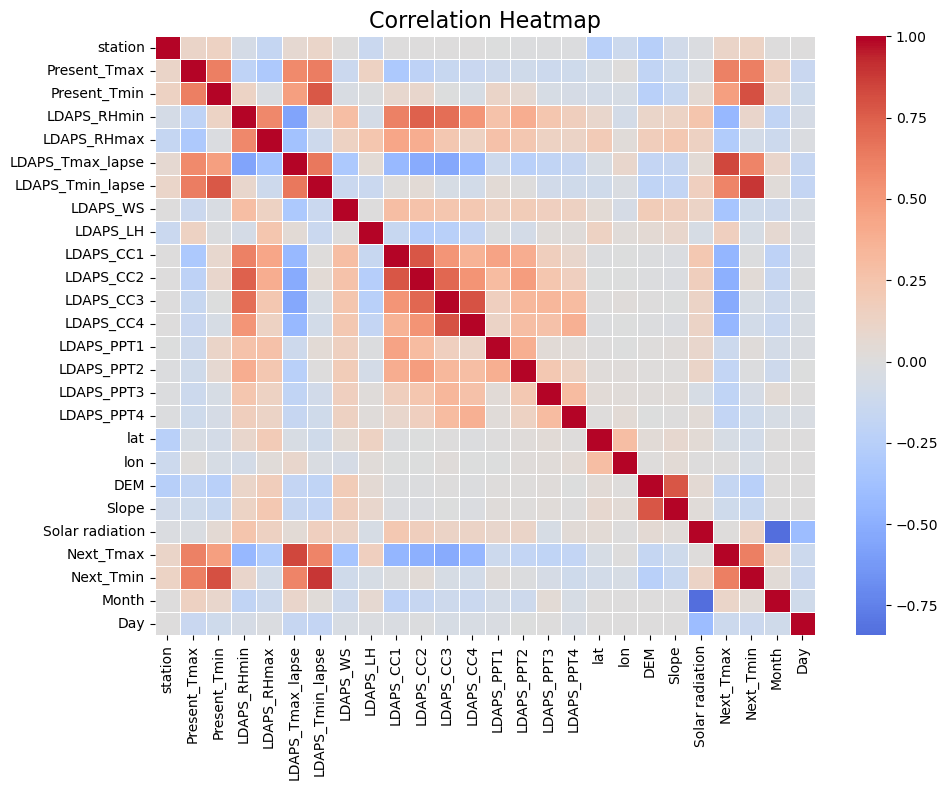

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Find correlations between the variables and visualize the correlation matrix using a:
#heatmap

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

**explanation**

- using `.corr()`, creating a matrix of correlated values first
- Using ChatGPT's suggestion with colors of the map ("ChatGPT", 5.2, 2026).
- Using the heatmap we can easily identify highly correlated features.
- may need to remove features that are too similar.

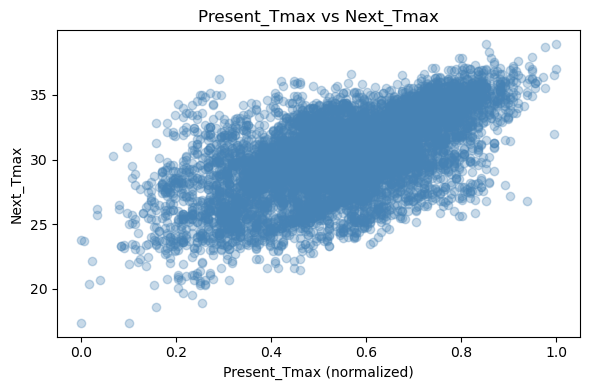

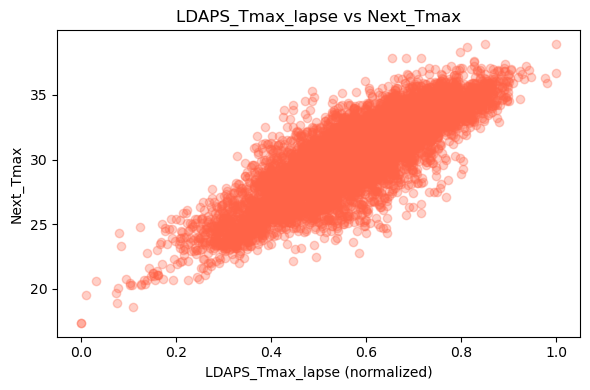

In [13]:
# scatterplot
# Scatterplot 1: Present_Tmax vs Next_Tmax
plt.figure(figsize=(6,4))
plt.scatter(df['Present_Tmax'], df['Next_Tmax'], alpha=0.3, color='steelblue')
plt.xlabel('Present_Tmax (normalized)')
plt.ylabel('Next_Tmax')
plt.title('Present_Tmax vs Next_Tmax')
plt.tight_layout()
plt.show()

# Scatterplot 2: LDAPS_Tmax_lapse vs Next_Tmax
plt.figure(figsize=(6,4))
plt.scatter(df['LDAPS_Tmax_lapse'], df['Next_Tmax'], alpha=0.3, color='tomato')
plt.xlabel('LDAPS_Tmax_lapse (normalized)')
plt.ylabel('Next_Tmax')
plt.title('LDAPS_Tmax_lapse vs Next_Tmax')
plt.tight_layout()
plt.show()

**explanation**

- both scatterplots shows an upward trend (positive relationship)
- plot before modeling to show if relationship is linear. If it is, linear regression may work well

In [14]:
# Designate all features, excluding the two last columns ("Next_Tmax" and "Next_Tmin"), as X_variables.
# Add a column name "Next_Taverage". 
#The values in this column is the average value of column "Next_Tmin" and "Next_Tmax". Assign the "Next_Taverage" column as Y_variable.

df['Next_Taverage'] = (df['Next_Tmax'] + df['Next_Tmin']) / 2

#X = all columns except the last two original targets + new target
X = df.drop(columns=['Next_Tmax', 'Next_Tmin', 'Next_Taverage'])
Y = df['Next_Taverage']

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("\nX columns:", X.columns.tolist())

X shape: (7752, 24)
Y shape: (7752,)

X columns: ['station', 'Present_Tmax', 'Present_Tmin', 'LDAPS_RHmin', 'LDAPS_RHmax', 'LDAPS_Tmax_lapse', 'LDAPS_Tmin_lapse', 'LDAPS_WS', 'LDAPS_LH', 'LDAPS_CC1', 'LDAPS_CC2', 'LDAPS_CC3', 'LDAPS_CC4', 'LDAPS_PPT1', 'LDAPS_PPT2', 'LDAPS_PPT3', 'LDAPS_PPT4', 'lat', 'lon', 'DEM', 'Slope', 'Solar radiation', 'Month', 'Day']


**explanation**

- Assigning X (Features) and Y (Target)
- The model will train on one portion and test on the others

In [17]:
corr_matrix = X.corr().abs()

threshold = 0.9
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

X_reduced = X.drop(columns=to_drop)

print("Columns to drop:", to_drop)

Columns to drop: set()


**explanation**

- I set the threshold to be 0.9 after asking ChatGPT ("ChatGPT", 5.2, 2026) and Claude , which gave different answers. 0.9 seems to be the standard and reasonable treshold to remove correlated variables.
- After running the test, no features is above the threshold and need to be removed

**references**

OpenAI. (2026). ChatGPT (5.2) [Large language model]. https://chat.openai.com/

Anthropic. (2026). Claude (4.6) [Large language model]. https://claude.ai/